In [1]:
#change the path to your working directory

base_dir = "/tgen_labs/barthel/projects/Jenkins_Mayo/aneuploidy/"
setwd(base_dir)

In [2]:
library(ComplexHeatmap)
library(circlize)
#library(gridExtra)
library(RColorBrewer)
library(ggpubr)
library(tidyverse)
library(ggplot2)
library(dplyr)
library(corrplot)
library(circlize)


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements a

In [33]:
#load the data files

summary_file = read.csv(file = "Glioma_v2_seg_stats.txt", header = TRUE, sep = "\t")
summary_file2 = read.csv(file = "Glioma_v2_output_taylor_aneuploidy.txt", header = TRUE, sep = "\t")
summary_file3 = read.csv(file = "Glioma_v2_CNV_stats.txt", header = TRUE, sep = "\t")


In [34]:
head(summary_file)
head(summary_file3)

,SampleID,fnum_seg,fwmean,fwsd,fnum_seg_loss,fwmean_loss,fwsd_loss,fnum_seg_gain,fwmean_gain,fwsd_gain
,<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,2436A,176,1.009581,156.0256,16,0.7956778,260.5310,7,1.157730,235.3149
2,3188,114,1.027025,160.9631,56,0.6978061,305.2345,85,1.236155,569.5360
3,3988,241,1.014360,158.3961,58,0.8223537,182.8437,33,1.217563,317.5744
4,6265D,100,1.053719,160.2933,55,0.7115023,471.9256,42,1.196481,1172.6887
5,6266D,178,1.006913,177.7799,48,0.8457312,132.4736,24,1.185813,345.9682
6,6269C,220,1.006723,133.1552,109,0.8205919,98.1927,92,1.208528,205.2897


,SampleID,seqnames,arm,arm_call,arm_num_seg,arm_cr_wmean,arm_cr_wsd
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
1,6478A,chr4,4p,0,2,1.0508593,278.6570
2,6298B,chr4,4p,0,2,0.9986684,163.3790
3,6483C,chr4,4p,0,4,1.0274257,153.1851
4,6266D,chr4,4p,0,4,1.0363533,198.2503
5,2436A,chr21,21p,0,NA,NA,NA
6,6414C,chr21,21p,0,NA,NA,NA


In [35]:
head(summary_file2)

,SampleID,aneuploidy_score,aneuploidy_amp_score,aneuploidy_del_score,max_loss_arm_n,max_loss_arm_wmean,max_loss_arm_wsd,max_gain_arm_n,max_gain_arm_wmean,max_gain_arm_wsd
,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,2436A,0,0,0,2,0.6911850,518.77180,2,1.090957,121.6615
2,3188,10,5,5,7,0.5904620,49.18453,8,1.449082,186.3352
3,3988,3,2,1,6,0.7432257,145.35260,3,1.464450,131.7548
4,6265D,1,0,1,5,0.5451189,492.26957,2,1.079414,182.9551
5,6266D,1,1,0,2,0.9506976,138.28511,8,1.301972,138.8279
6,6269C,2,1,1,2,0.7418210,332.95765,2,1.314523,313.2090


In [36]:

# Load clinical data with standard tab-delimited settings
clin_dat <- read.delim(
  file   = "/home/mjehangir/telomere-sv-analysis/data/clinical_data_merged.txt", 
  header = TRUE, 
  sep    = "\t"
)

In [37]:
head(clin_dat, n=20)
# Remove rows with any NA values
clin_dat <- na.omit(clin_dat)
head(clin_dat, n=2)


,ID,Age,Grade,CDKN2A.B,TP53,ATRX,onco_Alterations,ONT_Alterations,surgical,dead,days
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<int>
1,2436A,NA,3,NA,NA,NA,5,40,,1,4629
2,3188,NA,3,NA,NA,NA,16,107,,1,1349
3,3988,0,2,2,0,0,17,105,,1,1536
4,6265D,33,3,1,0,0,42,87,,1,950
5,6266D,40,2,1,0,0,28,105,,1,1195
6,6269C,23,3,2,0,0,14,214,,0,2300
7,6277A,40,3,1,0,0,70,138,,not available,NA
8,6285B,64,3,1,2,2,7,66,,0,2337
9,6298B,34,3,2,0,2,6,40,,0,0


,ID,Age,Grade,CDKN2A.B,TP53,ATRX,onco_Alterations,ONT_Alterations,surgical,dead,days
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<int>
3,3988,0,2,2,0,0,17,105,,1,1536
4,6265D,33,3,1,0,0,42,87,,1,950


In [38]:
head(summary_file2)

,SampleID,aneuploidy_score,aneuploidy_amp_score,aneuploidy_del_score,max_loss_arm_n,max_loss_arm_wmean,max_loss_arm_wsd,max_gain_arm_n,max_gain_arm_wmean,max_gain_arm_wsd
,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,2436A,0,0,0,2,0.6911850,518.77180,2,1.090957,121.6615
2,3188,10,5,5,7,0.5904620,49.18453,8,1.449082,186.3352
3,3988,3,2,1,6,0.7432257,145.35260,3,1.464450,131.7548
4,6265D,1,0,1,5,0.5451189,492.26957,2,1.079414,182.9551
5,6266D,1,1,0,2,0.9506976,138.28511,8,1.301972,138.8279
6,6269C,2,1,1,2,0.7418210,332.95765,2,1.314523,313.2090


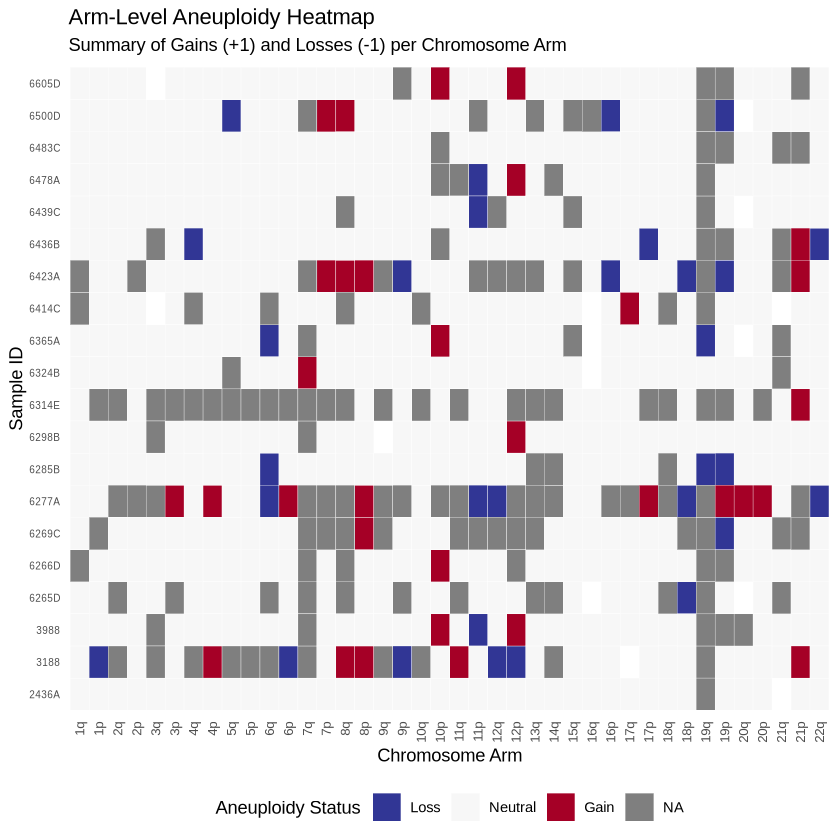

In [31]:

# 1. Prepare the data for plotting
# We fix the sorting so chromosomes appear in order (1, 2, 3...) and 'p' comes before 'q'
plot_data <- summary_file3 %>%
  mutate(
    # Extract chromosome number for sorting
    chr_num = as.numeric(gsub("[pq]", "", arm)),
    # Extract arm letter
    arm_let = gsub("[0-9]", "", arm)
  ) %>%
  arrange(chr_num, desc(arm_let)) %>%
  mutate(arm = factor(arm, levels = unique(arm)))

# 2. Create the Heatmap
ggplot(plot_data, aes(x = arm, y = SampleID, fill = as.factor(arm_call))) +
  geom_tile(color = "white", linewidth = 0.1) +
  
  # Set Colors: Dark Blue for Loss (-1), White for Neutral (0), Dark Red for Gain (1)
  scale_fill_manual(
    values = c("-1" = "#313695", "0" = "#f7f7f7", "1" = "#a50026"),
    labels = c("Loss", "Neutral", "Gain"),
    name = "Aneuploidy Status"
  ) +
  
  # Labels and Title
  labs(
    title = "Arm-Level Aneuploidy Heatmap",
    subtitle = "Summary of Gains (+1) and Losses (-1) per Chromosome Arm",
    x = "Chromosome Arm",
    y = "Sample ID"
  ) +
  
  # Theme and Aesthetics
  theme_minimal() +
  theme(
    # Rotate x-axis labels so they don't overlap
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 8),
    axis.text.y = element_text(size = 6),
    panel.grid = element_blank(),
    legend.position = "bottom"
  )